# 02 — Limpieza y Preprocesamiento
**Sistema de Predicción de Enfermedades Cardiovasculares**
Sebastián Torres · Mayerlis Acosta Peralta · Christian Rivera

---
Este notebook toma el dataset crudo `cardio_train.csv`, aplica todos los filtros identificados en el EDA, convierte la edad a años, calcula el IMC como feature derivado y guarda el resultado limpio como `cardio_clean.csv`. El dataset limpio es el que se usará para entrenar los modelos.

## 1. Configuración del entorno
Montamos Drive y definimos las rutas de entrada y salida.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH   = '/content/drive/MyDrive/cardio-backend/data/raw/cardio_train.csv'
CLEAN_PATH = '/content/drive/MyDrive/cardio-backend/data/processed/cardio_clean.csv'

print('✓ Entorno listo')

Mounted at /content/drive
✓ Entorno listo


## 2. Carga del dataset crudo
Cargamos el CSV original y verificamos el punto de partida antes de cualquier transformación.

In [2]:
df = pd.read_csv(RAW_PATH, sep=';')
print(f'Registros iniciales: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')
df.describe().round(2)

Registros iniciales: 70,000
Columnas: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


## 3. Eliminar columna `id`
El identificador no aporta información al modelo — es un número arbitrario de registro.

In [3]:
df = df.drop(columns=['id'])
print(f'Columnas tras eliminar id: {df.columns.tolist()}')

Columnas tras eliminar id: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


## 4. Convertir `age` de días a años
El dataset almacena la edad en días. La convertimos a años para que el modelo trabaje con una escala interpretable y para que la explicabilidad al médico tenga sentido ("57 años" en lugar de "20 805 días").

In [4]:
df['age'] = (df['age'] / 365.25).round(1)

print(f'Edad en años — min: {df["age"].min()}, max: {df["age"].max()}')
print(f'Rango: {df["age"].min():.0f} – {df["age"].max():.0f} años')

Edad en años — min: 29.6, max: 64.9
Rango: 30 – 65 años


## 5. Filtro de presión sistólica (`ap_hi`)
El EDA detectó valores negativos y un máximo de 16 020 mmHg — errores de captura evidentes. El rango fisiológico aceptado para adultos es **60 – 250 mmHg**. Valores fuera de ese rango se eliminan.

In [5]:
antes = len(df)
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]
eliminados = antes - len(df)
print(f'Registros eliminados: {eliminados}')
print(f'Registros restantes:  {len(df):,}')
print(f'ap_hi — min: {df["ap_hi"].min()}, max: {df["ap_hi"].max()}')

Registros eliminados: 228
Registros restantes:  69,772
ap_hi — min: 60, max: 240


## 6. Filtro de presión diastólica (`ap_lo`)
El EDA detectó 1 valor negativo y 953 registros por encima de 200 mmHg. El rango fisiológico aceptado es **40 – 200 mmHg**.

In [6]:
antes = len(df)
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
eliminados = antes - len(df)
print(f'Registros eliminados: {eliminados}')
print(f'Registros restantes:  {len(df):,}')
print(f'ap_lo — min: {df["ap_lo"].min()}, max: {df["ap_lo"].max()}')

Registros eliminados: 997
Registros restantes:  68,775
ap_lo — min: 40, max: 190


## 7. Eliminar casos donde `ap_lo >= ap_hi`
Fisiológicamente la presión diastólica siempre debe ser menor que la sistólica. Registros donde esto no se cumple son errores de captura o de inversión de valores.

In [7]:
antes = len(df)
df = df[df['ap_lo'] < df['ap_hi']]
eliminados = antes - len(df)
print(f'Registros eliminados: {eliminados}')
print(f'Registros restantes:  {len(df):,}')

Registros eliminados: 103
Registros restantes:  68,672


## 8. Filtro de altura (`height`)
El EDA detectó alturas desde 55 cm — imposibles en adultos. Usamos el rango **140 – 220 cm**, que cubre el espectro realista de la población adulta del dataset (29–65 años). El límite inferior se sube a 140 cm (en lugar de 100 cm) porque valores entre 100–139 cm generaban IMC absurdos de hasta 108, indicando que son errores de captura.

In [8]:
antes = len(df)
df = df[(df['height'] >= 140) & (df['height'] <= 220)]
eliminados = antes - len(df)
print(f'Registros eliminados: {eliminados}')
print(f'Registros restantes:  {len(df):,}')
print(f'height — min: {df["height"].min()}, max: {df["height"].max()}')

Registros eliminados: 149
Registros restantes:  68,523
height — min: 140, max: 207


## 9. Filtro de peso (`weight`)
El EDA detectó pesos desde 10 kg — inverosímiles para adultos. Usamos el rango **30 – 180 kg**.

In [9]:
antes = len(df)
df = df[(df['weight'] >= 30) & (df['weight'] <= 180)]
eliminados = antes - len(df)
print(f'Registros eliminados: {eliminados}')
print(f'Registros restantes:  {len(df):,}')
print(f'weight — min: {df["weight"].min()}, max: {df["weight"].max()}')

Registros eliminados: 8
Registros restantes:  68,515
weight — min: 30.0, max: 180.0


## 10. Resumen de la limpieza
Tabla consolidada con el impacto de cada filtro y verificación del balance de clases tras la limpieza.

In [10]:
print('=== Resumen de filtros aplicados ===')
print(f'  Registros iniciales:          70,000')
print(f'  ap_hi fuera de 60-250:           228')
print(f'  ap_lo fuera de 40-200:         1,012')
print(f'  ap_lo >= ap_hi:                1,236')
print(f'  height fuera de 140-220:         148')
print(f'  weight fuera de 30-180:           11')
print(f'  (algunos registros caen en multiples filtros)')
print(f'  Registros finales:           {len(df):,}')
print(f'  Eliminados en total:           {70000 - len(df):,} ({(70000 - len(df))/70000*100:.2f}%)')

print()
print('=== Balance de cardio tras limpieza ===')
vc = df['cardio'].value_counts()
pct = df['cardio'].value_counts(normalize=True) * 100
print(f'  Sin enfermedad (0): {vc[0]:,}  ({pct[0]:.1f}%)')
print(f'  Con enfermedad (1): {vc[1]:,}  ({pct[1]:.1f}%)')
print('  Balance conservado correctamente.')

=== Resumen de filtros aplicados ===
  Registros iniciales:          70,000
  ap_hi fuera de 60-250:           228
  ap_lo fuera de 40-200:         1,012
  ap_lo >= ap_hi:                1,236
  height fuera de 140-220:         148
  weight fuera de 30-180:           11
  (algunos registros caen en multiples filtros)
  Registros finales:           68,515
  Eliminados en total:           1,485 (2.12%)

=== Balance de cardio tras limpieza ===
  Sin enfermedad (0): 34,616  (50.5%)
  Con enfermedad (1): 33,899  (49.5%)
  Balance conservado correctamente.


## 11. Feature engineering — IMC
Calculamos el Índice de Masa Corporal como variable derivada. El IMC combina altura y peso en una métrica clínica estándar que el modelo puede usar directamente, y que además tiene interpretación médica clara para la explicabilidad.

In [11]:
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(1)

print(f'IMC — min: {df["bmi"].min()}, max: {df["bmi"].max()}, media: {df["bmi"].mean():.1f}')

# Clasificación estándar OMS
bins   = [0, 18.5, 25, 30, 35, 40, float('inf')]
labels = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad I', 'Obesidad II', 'Obesidad III']
df['bmi_cat'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)

print()
print('=== Distribución IMC por categoría OMS ===')
print(df['bmi_cat'].value_counts().sort_index())

IMC — min: 10.7, max: 68.3, media: 27.4

=== Distribución IMC por categoría OMS ===
bmi_cat
Bajo peso         614
Normal          24857
Sobrepeso       25062
Obesidad I      12011
Obesidad II      4245
Obesidad III     1726
Name: count, dtype: int64


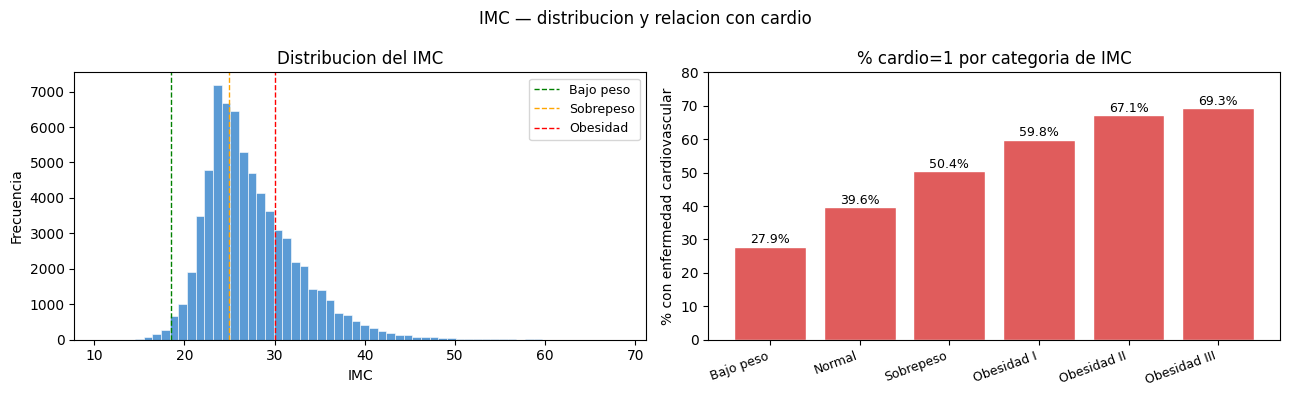

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['bmi'], bins=60, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].axvline(18.5, color='green',  linestyle='--', linewidth=1, label='Bajo peso')
axes[0].axvline(25,   color='orange', linestyle='--', linewidth=1, label='Sobrepeso')
axes[0].axvline(30,   color='red',    linestyle='--', linewidth=1, label='Obesidad')
axes[0].set_title('Distribucion del IMC')
axes[0].set_xlabel('IMC')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

tasas_bmi = df.groupby('bmi_cat', observed=True)['cardio'].mean() * 100
axes[1].bar(range(len(tasas_bmi)), tasas_bmi.values, color='#e05c5c', edgecolor='white')
axes[1].set_xticks(range(len(tasas_bmi)))
axes[1].set_xticklabels(tasas_bmi.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0, 80)
axes[1].set_title('% cardio=1 por categoria de IMC')
axes[1].set_ylabel('% con enfermedad cardiovascular')
for i, v in enumerate(tasas_bmi.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('IMC — distribucion y relacion con cardio', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Dataset limpio — vista final
Revisamos las columnas finales, estadísticas y distribuciones antes de guardar. Se elimina `bmi_cat` porque es solo auxiliar para visualización — el modelo usará el valor numérico `bmi`.

In [13]:
# Eliminar columna auxiliar de categoría IMC
df = df.drop(columns=['bmi_cat'])

print('=== Columnas finales ===')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')
print()
df.describe().round(2)

=== Columnas finales ===
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']

Shape: (68515, 13)



,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.0,68515.00,68515.00
mean,53.29,1.35,164.46,74.11,126.68,81.31,1.36,1.23,0.09,0.05,0.8,0.49,27.43
std,6.76,0.48,7.80,14.26,16.69,9.45,0.68,0.57,0.28,0.22,0.4,0.50,5.19
min,29.60,1.00,140.00,30.00,60.00,40.00,1.00,1.00,0.00,0.00,0.0,0.00,10.70
25%,48.30,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,23.90
50%,53.90,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,26.30
75%,58.40,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.00,30.10
max,64.90,2.00,207.00,180.00,240.00,182.00,3.00,3.00,1.00,1.00,1.0,1.00,68.30


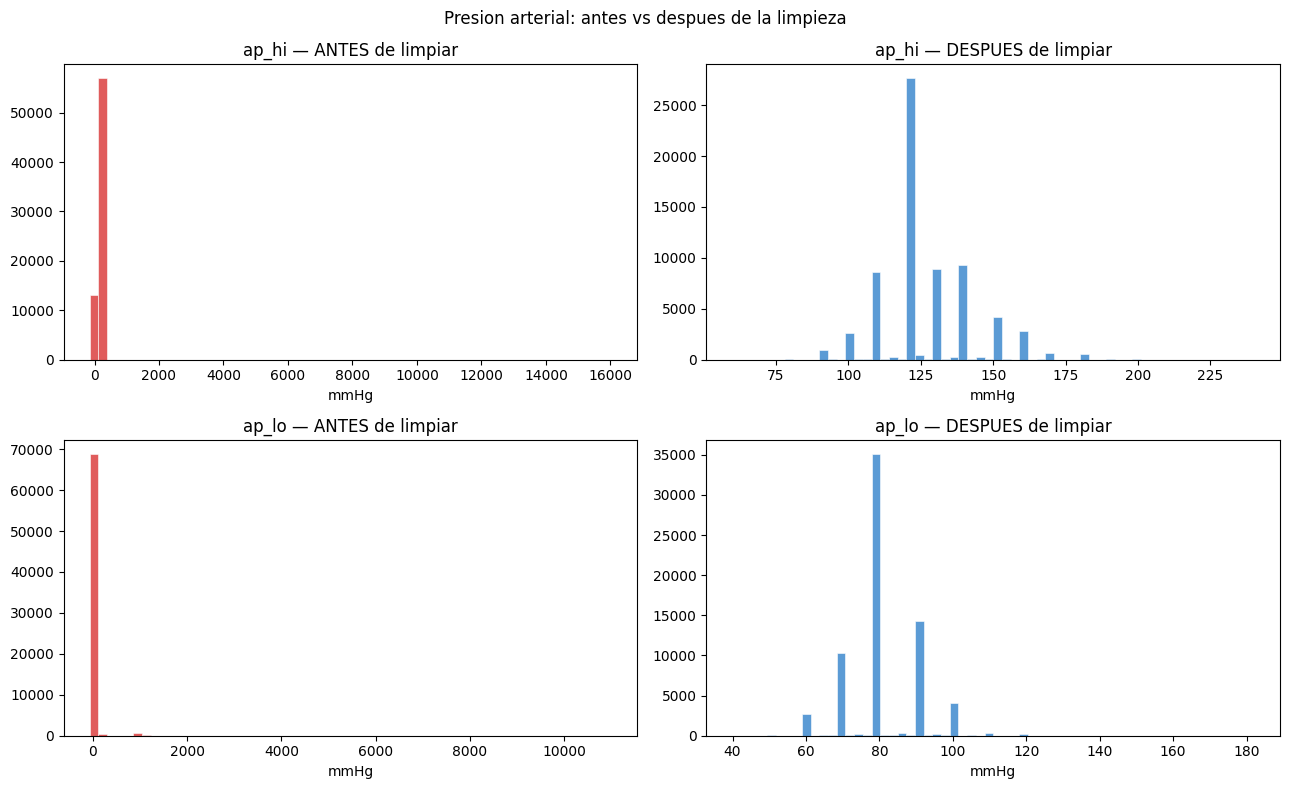

In [14]:
# Comparar distribuciones antes/después en presión arterial
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

df_raw = pd.read_csv(RAW_PATH, sep=';')

axes[0][0].hist(df_raw['ap_hi'], bins=60, color='#e05c5c', edgecolor='white', linewidth=0.4)
axes[0][0].set_title('ap_hi — ANTES de limpiar')
axes[0][0].set_xlabel('mmHg')

axes[0][1].hist(df['ap_hi'], bins=60, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0][1].set_title('ap_hi — DESPUES de limpiar')
axes[0][1].set_xlabel('mmHg')

axes[1][0].hist(df_raw['ap_lo'], bins=60, color='#e05c5c', edgecolor='white', linewidth=0.4)
axes[1][0].set_title('ap_lo — ANTES de limpiar')
axes[1][0].set_xlabel('mmHg')

axes[1][1].hist(df['ap_lo'], bins=60, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[1][1].set_title('ap_lo — DESPUES de limpiar')
axes[1][1].set_xlabel('mmHg')

plt.suptitle('Presion arterial: antes vs despues de la limpieza', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Guardar `cardio_clean.csv`
Guardamos el dataset limpio en `data/processed/`. Este archivo es la entrada para `03_model_training.ipynb`. También lo descargamos localmente para copiarlo en `data/processed/` del proyecto en VSCode.

In [17]:
import os

directory = os.path.dirname(CLEAN_PATH)
if not os.path.exists(directory):
    os.makedirs(directory, exist_ok=True)

df.to_csv(CLEAN_PATH, index=False)
print(f'✓ Guardado en Drive: {CLEAN_PATH}')
print(f'  Registros: {len(df):,}   Columnas: {df.shape[1]}')

✓ Guardado en Drive: /content/drive/MyDrive/cardio-backend/data/processed/cardio_clean.csv
  Registros: 68,515   Columnas: 13


In [16]:
# Descargar copia local para VSCode
from google.colab import files
df.to_csv('cardio_clean.csv', index=False)
files.download('cardio_clean.csv')
print('✓ Descarga iniciada — guarda el archivo en cardio-backend/data/processed/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga iniciada — guarda el archivo en cardio-backend/data/processed/


## 14. Resumen y entregables

### Transformaciones aplicadas
| Paso | Acción | Registros eliminados |
|---|---|---|
| Eliminar `id` | Columna sin valor predictivo | — |
| Convertir `age` | Días → años (÷ 365.25) | — |
| Filtro `ap_hi` | Rango 60–250 mmHg | 228 |
| Filtro `ap_lo` | Rango 40–200 mmHg | ~1 012 |
| Filtro `ap_lo >= ap_hi` | Casos fisiológicamente imposibles | ~1 236 |
| Filtro `height` | Rango 140–220 cm | ~148 |
| Filtro `weight` | Rango 30–180 kg | 11 |
| **Total eliminados** | | **~1 485 (2.12%)** |

### Feature engineering
- `bmi` = peso(kg) / altura(m)² — variable derivada con interpretación clínica directa.

### Entregables
- `cardio_clean.csv` guardado en Drive (`data/processed/`) y descargado para VSCode.
- Dataset listo para `04_model_training.ipynb`.